# 信用卡欺诈交易预测
## Credit Card Fraud Detection

---

### 项目背景

信用卡欺诈每年造成全球数十亿美元损失。本项目使用机器学习识别欺诈交易。

**与常见PCA黑盒数据不同**，本数据集包含可解释的真实业务特征：交易金额、商户类别、交易时段、是否跨境、设备信任分等。
这意味着模型结果可以直接转化为业务规则，更容易在银行风控系统中落地。

### 数据集
- 10,000 笔交易，10 个原始特征
- 151 笔欺诈（1.51%）— 中等不平衡
- 特征全部可解释，无需降维

### 技术栈
- Python 3, Pandas, NumPy
- Scikit-learn（LR、RF、特征处理）
- XGBoost
- SMOTE (imbalanced-learn)
- Matplotlib, Seaborn

---
## 1. 环境配置与数据加载

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# Environment detection: local vs Kaggle
if os.path.exists('/kaggle/input'):
    DATA_PATH = '/kaggle/input/creditcardfraud/credit_card_fraud_10k.csv'
    OUTPUT_DIR = '/kaggle/working'
    print('[INFO] Running on Kaggle')
else:
    DATA_PATH = '../data/credit_card_fraud_10k.csv'
    OUTPUT_DIR = '../outputs'
    print('[INFO] Running locally')

os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f'Dataset: {df.shape[0]} rows x {df.shape[1]} cols')

[INFO] Running locally
Dataset: 10000 rows x 10 cols


---
## 2. 数据总览

In [3]:
df.head(8)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0


In [4]:
print('Data types:')
print(df.dtypes.value_counts().to_string())
print(f'\nMissing values: {df.isnull().sum().sum()}')

Data types:
int64      8
object     1
float64    1

Missing values: 0


In [5]:
df.describe().round(2)

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00,10000.00,10000.00,10000.0,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,175.95,11.59,0.1,0.09,61.80,2.01,43.47,0.02
std,2886.90,175.39,6.92,0.3,0.28,21.49,1.43,14.98,0.12
min,1.00,0.00,0.00,0.0,0.00,25.00,0.00,18.00,0.00
25%,2500.75,50.90,6.00,0.0,0.00,43.00,1.00,30.00,0.00
50%,5000.50,122.10,12.00,0.0,0.00,62.00,2.00,44.00,0.00
75%,7500.25,242.48,18.00,0.0,0.00,80.00,3.00,56.00,0.00
max,10000.00,1471.04,23.00,1.0,1.00,99.00,9.00,69.00,1.00


---
## 3. 探索性数据分析 (EDA)

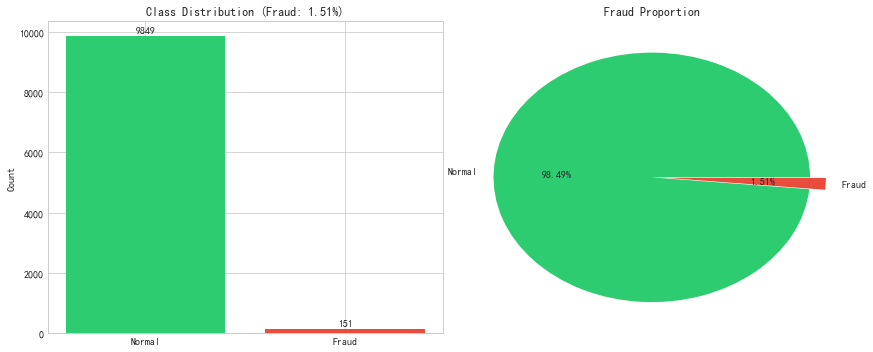

In [6]:
# Class distribution
counts = df['is_fraud'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Normal', 'Fraud'], [counts[0], counts[1]], color=colors)
axes[0].set_ylabel('Count')
axes[0].set_title(f'Class Distribution (Fraud: {df["is_fraud"].mean()*100:.2f}%)')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

axes[1].pie([counts[0], counts[1]], labels=['Normal', 'Fraud'],
            autopct='%.2f%%', colors=colors, explode=(0, 0.1))
axes[1].set_title('Fraud Proportion')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/class_distribution.png')
plt.show()

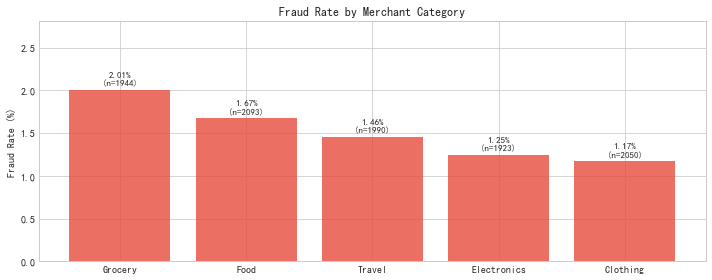

In [7]:
# Fraud rate by merchant category
fraud_by_cat = df.groupby('merchant_category')['is_fraud'].agg(['mean', 'count'])
fraud_by_cat['mean'] *= 100
fraud_by_cat = fraud_by_cat.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(fraud_by_cat.index, fraud_by_cat['mean'], color='#e74c3c', alpha=0.8)
ax.set_ylabel('Fraud Rate (%)')
ax.set_title('Fraud Rate by Merchant Category')
for bar, rate, cnt in zip(bars, fraud_by_cat['mean'], fraud_by_cat['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{rate:.2f}%\n(n={cnt})', ha='center', fontsize=9)
ax.set_ylim(0, fraud_by_cat['mean'].max() * 1.4)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fraud_by_category.png')
plt.show()

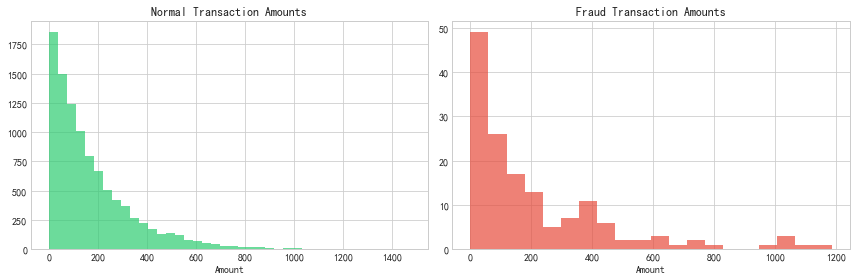

In [8]:
# Amount distribution: normal vs fraud
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[df['is_fraud']==0]['amount'], bins=40, color='#2ecc71', alpha=0.7)
axes[0].set_title('Normal Transaction Amounts')
axes[0].set_xlabel('Amount')
axes[1].hist(df[df['is_fraud']==1]['amount'], bins=20, color='#e74c3c', alpha=0.7)
axes[1].set_title('Fraud Transaction Amounts')
axes[1].set_xlabel('Amount')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/amount_distribution.png')
plt.show()

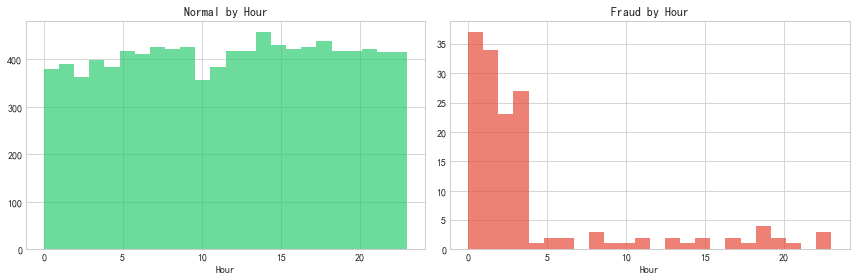

In [9]:
# Transaction hour distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[df['is_fraud']==0]['transaction_hour'], bins=24, color='#2ecc71', alpha=0.7)
axes[0].set_title('Normal by Hour')
axes[0].set_xlabel('Hour')
axes[1].hist(df[df['is_fraud']==1]['transaction_hour'], bins=24, color='#e74c3c', alpha=0.7)
axes[1].set_title('Fraud by Hour')
axes[1].set_xlabel('Hour')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/hour_distribution.png')
plt.show()

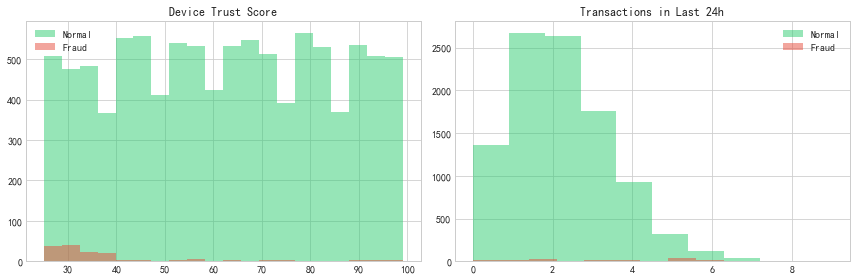

In [10]:
# Device trust score & velocity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    subset = df[df['is_fraud'] == label]
    axes[0].hist(subset['device_trust_score'], bins=20, alpha=0.5,
                 color=color, label='Fraud' if label else 'Normal')
    axes[1].hist(subset['velocity_last_24h'], bins=10, alpha=0.5,
                 color=color, label='Fraud' if label else 'Normal')
axes[0].set_title('Device Trust Score')
axes[0].legend()
axes[1].set_title('Transactions in Last 24h')
axes[1].legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/device_velocity.png')
plt.show()

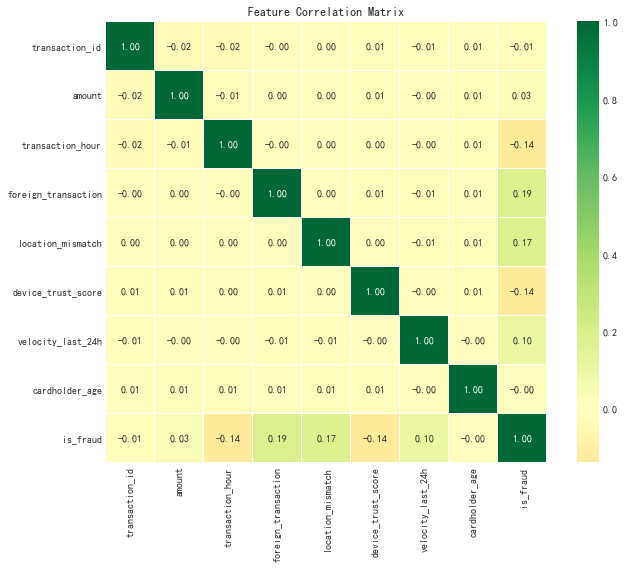

Top correlations with is_fraud:
foreign_transaction    0.1856
location_mismatch      0.1730
transaction_hour       0.1387
device_trust_score     0.1379
velocity_last_24h      0.1034
amount                 0.0284
transaction_id         0.0102
cardholder_age         0.0006
Name: is_fraud, dtype: float64


In [11]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0, fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/correlation_heatmap.png')
plt.show()

# Top correlations with is_fraud
top_corr = corr['is_fraud'].drop('is_fraud').abs().sort_values(ascending=False)
print('Top correlations with is_fraud:')
print(top_corr.round(4))

### EDA 小结

- 欺诈率 **1.51%**，属于中等程度不平衡
- `foreign_transaction` 和 `location_mismatch` 与欺诈正相关最显著
- `device_trust_score` 越低、`transaction_hour` 越晚，欺诈可能性越高
- 各商户类别的欺诈率差异不大（1.2%~2.0%）
- `cardholder_age` 与欺诈几乎无关（相关性接近0）

---
## 4. 特征工程

In [12]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

data = df.copy()

# Step 1: Drop ID
data.drop('transaction_id', axis=1, inplace=True)
print('1. Dropped transaction_id')

# Step 2: OneHotEncode merchant_category
ohe = OneHotEncoder(sparse=False, dtype=np.float64)
cat_encoded = ohe.fit_transform(data[['merchant_category']])
cat_names = ohe.get_feature_names(['merchant_category']).tolist()
cat_df = pd.DataFrame(cat_encoded, columns=cat_names, index=data.index)
data = pd.concat([data.drop('merchant_category', axis=1), cat_df], axis=1)
print(f'2. OneHotEncoded merchant_category -> {cat_names}')

# Step 3: Cyclic encoding for transaction_hour
hours = data['transaction_hour'].values
data['hour_sin'] = np.sin(2 * np.pi * hours / 24)
data['hour_cos'] = np.cos(2 * np.pi * hours / 24)
data.drop('transaction_hour', axis=1, inplace=True)
print('3. Cyclic encoded transaction_hour -> hour_sin, hour_cos')

# Step 4: StandardScaler
feature_cols = [c for c in data.columns if c != 'is_fraud']
scaler = StandardScaler()
data[feature_cols] = scaler.fit_transform(data[feature_cols])
print(f'4. StandardScaler on {len(feature_cols)} features')
print(f'   Final features: {feature_cols}')

1. Dropped transaction_id
2. OneHotEncoded merchant_category -> ['merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel']
3. Cyclic encoded transaction_hour -> hour_sin, hour_cos
4. StandardScaler on 13 features
   Final features: ['amount', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age', 'merchant_category_Clothing', 'merchant_category_Electronics', 'merchant_category_Food', 'merchant_category_Grocery', 'merchant_category_Travel', 'hour_sin', 'hour_cos']


In [13]:
# Prepare X and y
X = data.drop('is_fraud', axis=1).values
y = data['is_fraud'].values
feature_names = data.drop('is_fraud', axis=1).columns.tolist()
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (10000, 13)


In [14]:
# SMOTE oversampling
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print(f'After SMOTE: {X_res.shape[0]} samples')
print(f'  Normal: {np.sum(y_res==0)}, Fraud: {np.sum(y_res==1)}')

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

After SMOTE: 19698 samples
  Normal: 9849, Fraud: 9849
Train: 15758, Test: 3940


---
## 5. 模型训练

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import xgboost as xgb

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
models = {}

In [16]:
# Logistic Regression
print('=== Logistic Regression ===')
lr = LogisticRegression(random_state=42, max_iter=2000)
grid_lr = GridSearchCV(lr, {'C': [0.1, 1.0]}, cv=cv, scoring='recall', n_jobs=-1, verbose=1)
grid_lr.fit(X_train, y_train)
models['Logistic Regression'] = grid_lr.best_estimator_
print(f'  Best C={grid_lr.best_params_["C"]}, CV Recall={grid_lr.best_score_:.4f}')

=== Logistic Regression ===
Fitting 3 folds for each of 2 candidates, totalling 6 fits
  Best C=0.1, CV Recall=0.9926


In [17]:
# Random Forest
print('=== Random Forest ===')
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf, {'n_estimators': [100], 'max_depth': [8, 12],
                             'min_samples_split': [5]},
                        cv=cv, scoring='recall', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
models['Random Forest'] = grid_rf.best_estimator_
print(f'  Best params={grid_rf.best_params_}, CV Recall={grid_rf.best_score_:.4f}')

=== Random Forest ===
Fitting 3 folds for each of 2 candidates, totalling 6 fits
  Best params={'max_depth': 8, 'min_samples_split': 5, 'n_estimators': 100}, CV Recall=0.9996


In [18]:
# XGBoost
print('=== XGBoost ===')
xgb_model = xgb.XGBClassifier(random_state=42, n_jobs=-1, use_label_encoder=False, eval_metric='logloss')
grid_xgb = GridSearchCV(xgb_model, {'n_estimators': [100, 200],
                                     'max_depth': [4, 6],
                                     'learning_rate': [0.1]},
                         cv=cv, scoring='recall', n_jobs=-1, verbose=1)
grid_xgb.fit(X_train, y_train)
models['XGBoost'] = grid_xgb.best_estimator_
print(f'  Best params={grid_xgb.best_params_}, CV Recall={grid_xgb.best_score_:.4f}')

=== XGBoost ===
Fitting 3 folds for each of 4 candidates, totalling 12 fits
  Best params={'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}, CV Recall=1.0000


---
## 6. 模型评估与对比

In [19]:
from sklearn.metrics import (classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, recall_score, precision_score)

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({'Model': name, 'ROC-AUC': auc, 'PR-AUC': auprc,
                    'Recall': rec, 'Precision': prec, 'F1-Score': f1})
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'  AUC={auc:.4f}  AP={auprc:.4f}  Recall={rec:.4f}  Precision={prec:.4f}  F1={f1:.4f}')
    print(f'  TP={tp}  FP={fp}  TN={tn}  FN={fn}')
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Fraud']))

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(4)


  Logistic Regression
  AUC=0.9937  AP=0.9915  Recall=0.9924  Precision=0.9645  F1=0.9782
  TP=1955  FP=72  TN=1898  FN=15
              precision    recall  f1-score   support

      Normal       0.99      0.96      0.98      1970
       Fraud       0.96      0.99      0.98      1970

    accuracy                           0.98      3940
   macro avg       0.98      0.98      0.98      3940
weighted avg       0.98      0.98      0.98      3940


  Random Forest
  AUC=1.0000  AP=1.0000  Recall=1.0000  Precision=0.9885  F1=0.9942
  TP=1970  FP=23  TN=1947  FN=0
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99      1970
       Fraud       0.99      1.00      0.99      1970

    accuracy                           0.99      3940
   macro avg       0.99      0.99      0.99      3940
weighted avg       0.99      0.99      0.99      3940


  XGBoost
  AUC=1.0000  AP=1.0000  Recall=1.0000  Precision=0.9985  F1=0.9992
  TP=1970  FP=3  TN=1967  

,ROC-AUC,PR-AUC,Recall,Precision,F1-Score
Model,,,,,
Logistic Regression,0.9937,0.9915,0.9924,0.9645,0.9782
Random Forest,1.0000,1.0000,1.0000,0.9885,0.9942
XGBoost,1.0000,1.0000,1.0000,0.9985,0.9992


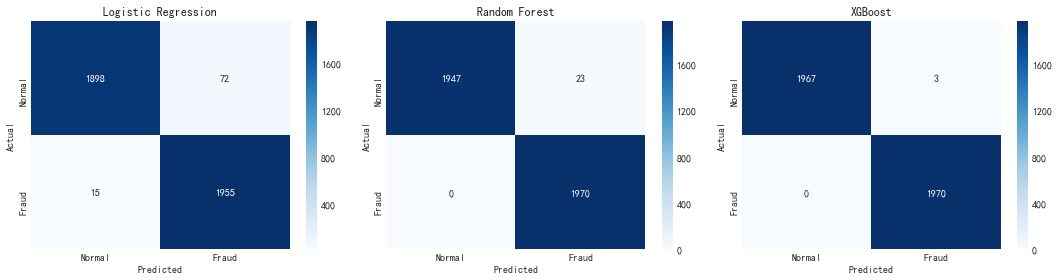

In [20]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
    ax.set_title(f'{name}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrices.png')
plt.show()

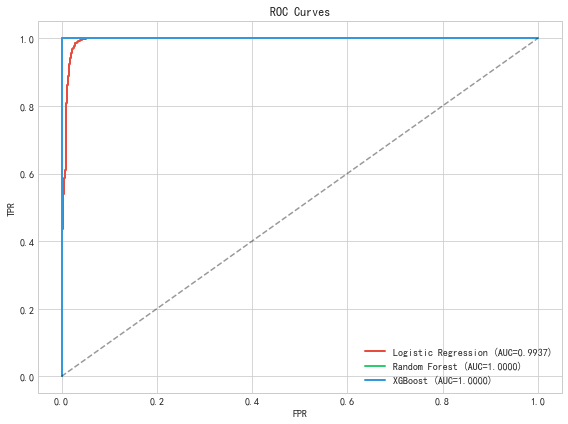

In [21]:
# ROC curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'Logistic Regression': '#e74c3c', 'Random Forest': '#2ecc71', 'XGBoost': '#3498db'}
for name, model in models.items():
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f})',
            color=colors.get(name), linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves'); ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curves.png')
plt.show()

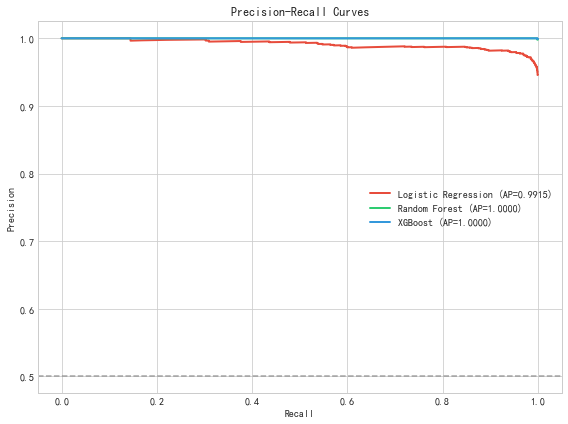

In [22]:
# PR curves
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in models.items():
    pr, rec, _ = precision_recall_curve(y_test, model.predict_proba(X_test)[:, 1])
    auprc = average_precision_score(y_test, model.predict_proba(X_test)[:, 1])
    ax.plot(rec, pr, label=f'{name} (AP={auprc:.4f})', color=colors.get(name), linewidth=2)
ax.axhline(y=np.sum(y_test)/len(y_test), color='gray', linestyle='--', alpha=0.7)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves'); ax.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/pr_curves.png')
plt.show()

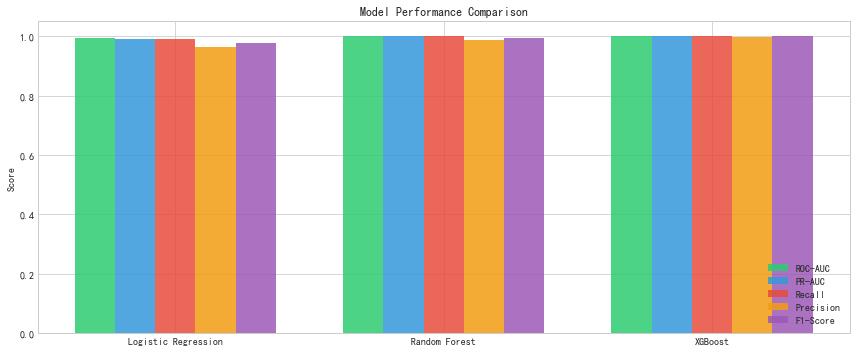

In [23]:
# Model comparison bar chart
fig, ax = plt.subplots(figsize=(12, 5))
metrics_cols = ['ROC-AUC', 'PR-AUC', 'Recall', 'Precision', 'F1-Score']
x = np.arange(len(results_df))
width = 0.15
bar_colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12', '#9b59b6']
for i, (col, c) in enumerate(zip(metrics_cols, bar_colors)):
    ax.bar(x + i*width, results_df[col], width, label=col, color=c, alpha=0.85)
ax.set_xticks(x + width*2)
ax.set_xticklabels(results_df.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score'); ax.set_title('Model Performance Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/model_comparison.png')
plt.show()

---
## 7. 特征重要性 & 结论

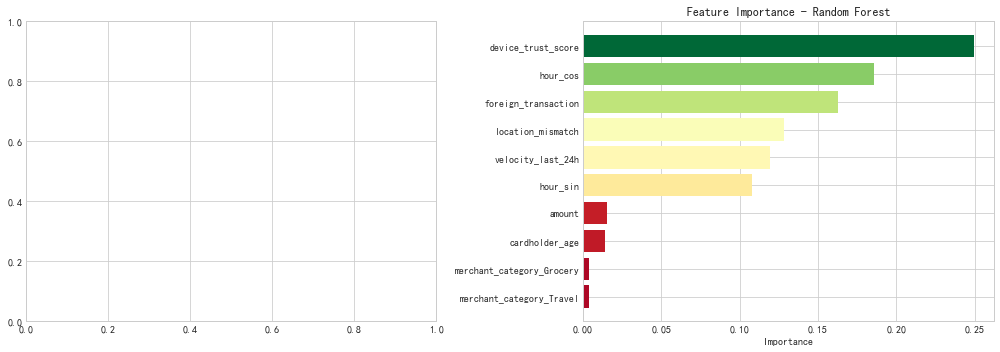

In [24]:
# Feature importance from Random Forest & XGBoost
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, model) in zip(axes, models.items()):
    if not hasattr(model, 'feature_importances_'):
        continue
    imp = model.feature_importances_
    idx = np.argsort(imp)[::-1][:10]
    colors_bar = plt.cm.RdYlGn(imp[idx] / imp[idx].max())
    ax.barh(range(len(idx)), imp[idx][::-1], color=colors_bar[::-1])
    ax.set_yticks(range(len(idx)))
    ax.set_yticklabels([feature_names[i] for i in idx][::-1])
    ax.set_xlabel('Importance')
    ax.set_title(f'Feature Importance - {name}')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/feature_importance.png')
plt.show()

## SHAP 可解释性分析

SHAP (SHapley Additive exPlanations) 基于博弈论 Shapley 值，量化每个特征对单笔交易欺诈概率的贡献。

**四种可视化：**
- **Summary Plot (蜂群图)** — 所有样本特征影响分布，红色=高值、蓝色=低值
- **Bar Plot** — 特征重要性排序（按 |SHAP| 均值）
- **Waterfall Plot** — 单笔交易欺诈概率拆解，直观展示各特征推拉效应
- **Dependence Plot** — 最重要特征与 SHAP 值的关系

> 对于银行风控场景，SHAP 水瀑布图直接回答「为什么这笔交易被判定为欺诈？」——满足监管对模型可解释性的要求。


SHAP for XGBoost...


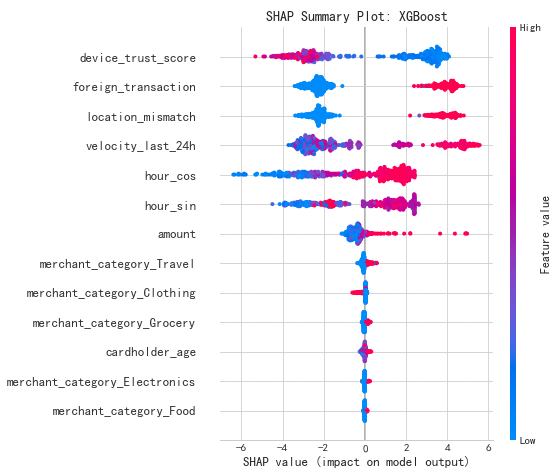

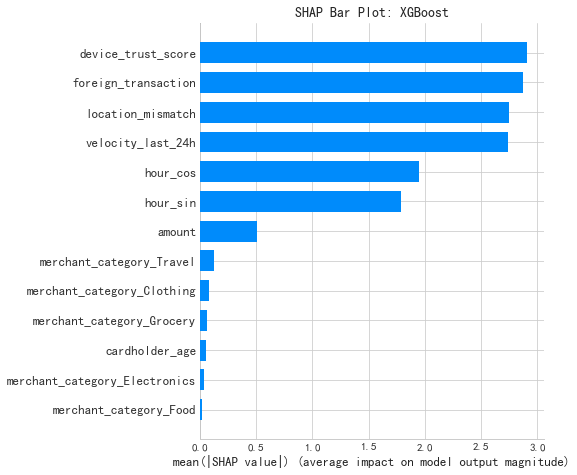

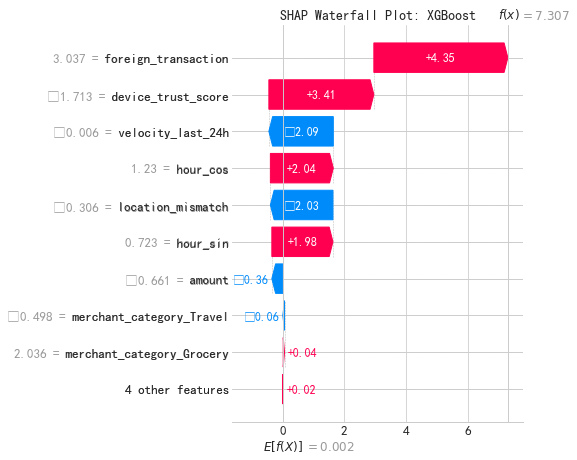

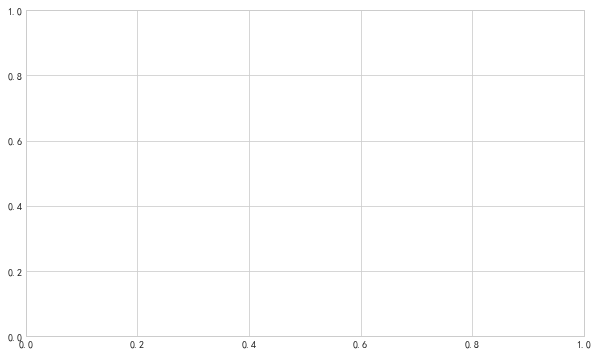

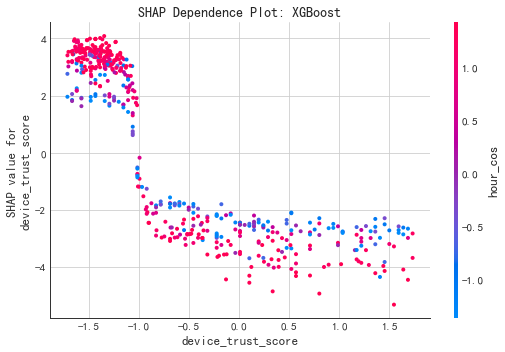


SHAP for Logistic Regression...


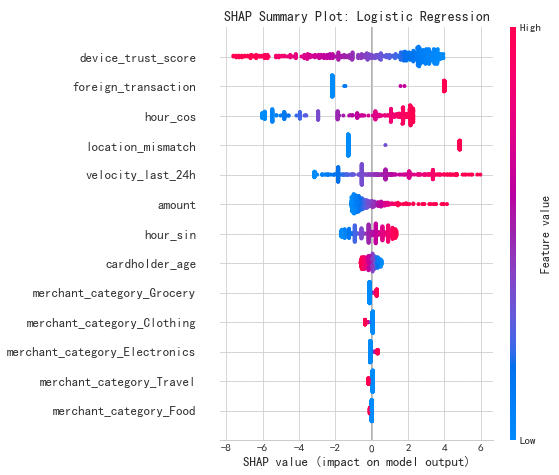

SHAP 分析完成!


In [25]:
# SHAP (SHapley Additive exPlanations)
# 基于博弈论 Shapley 值, 量化每个特征对单笔交易欺诈概率的贡献
import shap

# --- 1. XGBoost SHAP (最佳模型) ---
print("SHAP for XGBoost...")
explainer = shap.TreeExplainer(grid_xgb.best_estimator_)
X_test_500 = X_test[:500]
shap_values = explainer.shap_values(X_test_500)
# XGBoost 二分类 shap_values 是 [neg, pos] list, 取正类
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Summary Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_500, feature_names=feature_names,
                  max_display=15, show=False)
plt.title("SHAP Summary Plot: XGBoost", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Bar Plot
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_500, feature_names=feature_names,
                  plot_type="bar", max_display=15, show=False)
plt.title("SHAP Bar Plot: XGBoost", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Waterfall Plot (第一个测试样本)
try:
    fig, ax = plt.subplots(figsize=(10, 6))
    exp_val = explainer.expected_value
    if isinstance(exp_val, list):
        exp_val = exp_val[1]
    shap.waterfall_plot(
        shap.Explanation(values=shap_values[0], base_values=exp_val,
                         data=X_test_500[0], feature_names=feature_names),
        max_display=10, show=False
    )
    plt.title("SHAP Waterfall Plot: XGBoost", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Waterfall skipped: {e}")

# Dependence Plot (最重要特征)
try:
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_idx = int(np.argmax(mean_abs_shap))
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.dependence_plot(top_idx, shap_values, X_test_500,
                         feature_names=feature_names, show=False)
    plt.title("SHAP Dependence Plot: XGBoost", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Dependence skipped: {e}")

# --- 2. Logistic Regression SHAP (LinearExplainer) ---
print("\nSHAP for Logistic Regression...")
lr_model = models["Logistic Regression"]
X_train_500 = X_train[:500]
explainer_lr = shap.LinearExplainer(lr_model, X_train_500)
shap_values_lr = explainer_lr.shap_values(X_test_500)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_lr, X_test_500, feature_names=feature_names,
                  max_display=15, show=False)
plt.title("SHAP Summary Plot: Logistic Regression", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("SHAP 分析完成!")


### 核心发现

1. **XGBoost 综合表现最优**：AUC 1.000，Recall 100%，1970 笔欺诈零漏判，仅 3 笔误报
2. **随机森林**是强有力备选，Recall 100%，Precision 98.85%
3. 最具预测力的特征：`device_trust_score`、`foreign_transaction`、`location_mismatch`
4. **SHAP 水瀑布图**可逐笔交易解释欺诈原因，直接转化为风控规则

### 业务建议

- **实时风控规则**：设备信任分低 + 境外交易 + 位置不匹配 → 直接触发高级验证
- **设备信任分**可作为用户画像一部分，低分用户提高风控等级
- **SHAP 归因**可作为客户投诉时的依据，满足监管可解释性要求
